In [ ]:
# Instalação da biblioteca "ucilmlrepo", permite baixar o dataset neste colab sem ter que baixá-lo localmente
!pip install ucimlrepo

In [ ]:
# Instalação da biblioteca "optuna", para otimizar os testes de hiperparâmetros
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.9 MB/s eta 0:00:00


In [ ]:
# Imports gerais e definição do rng
RNG = 42

import pandas as pd
import numpy as np
import optuna as op

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import f1_score

from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt

In [ ]:
# Download do dataset sem codificação
from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

print(X)
print(y)

     buying  maint  doors persons lug_boot safety
0     vhigh  vhigh      2       2    small    low
1     vhigh  vhigh      2       2    small    med
2     vhigh  vhigh      2       2    small   high
3     vhigh  vhigh      2       2      med    low
4     vhigh  vhigh      2       2      med    med
...     ...    ...    ...     ...      ...    ...
1723    low    low  5more    more      med    med
1724    low    low  5more    more      med   high
1725    low    low  5more    more      big    low
1726    low    low  5more    more      big    med
1727    low    low  5more    more      big   high

[1728 rows x 6 columns]
      class
0     unacc
1     unacc
2     unacc
3     unacc
4     unacc
...     ...
1723   good
1724  vgood
1725  unacc
1726   good
1727  vgood

[1728 rows x 1 columns]


In [ ]:
# Separação em conjutno de treino (otimização de hiperparâmetros) e teste (para comparar os desempenhos dos modelos finais)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=RNG, shuffle=True, stratify=y)

In [ ]:
# Codificação dos atributos do dataset

# Todos os atributos categóricos em ordem de menos para mais magnitude (por coincidência, todos os atributos desse dataset são categóricos ordinais)
X_categories = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
X_orders = [
            ['low', 'med', 'high', 'vhigh'],
            ['low', 'med', 'high', 'vhigh'],
            ['2', '3', '4', '5more'],
            ['2', '4', 'more'],
            ['small', 'med', 'big'],
            ['low', 'med', 'high']
        ]

# Não sei porque, mas a MLP tá dando erro se a gente não codifica os labels também mesmo que no outro .ipynb estivesse funcionando sem problemas
Y_categories = ['class']
Y_orders = [
            ['unacc', 'acc', 'good', 'vgood']
          ]

# Encoder associa cada valor de cada ordem a um número de 0 a n-1 e então atualizamos o dataframe
encoder = OrdinalEncoder(categories=X_orders, dtype=np.int64)
encoder.set_output(transform="pandas") # Sem isso o encoder retorna um numpy array e não um dataframe pandas
X_train = encoder.fit_transform(X_train[X_categories])
X_test = encoder.fit_transform(X_test[X_categories])

encoder = OrdinalEncoder(categories=Y_orders, dtype=np.int64)
encoder.set_output(transform="pandas")
y_train = encoder.fit_transform(y_train[Y_categories])
y_test = encoder.fit_transform(y_test[Y_categories])

# Primeiro valor é total de instâncias no conjunto
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1382, 6)
(346, 6)
(1382, 1)
(346, 1)


In [ ]:
# Otimização de hiperparâmetros usando biblioteca optuna
# Hiperparâmetros buscam otimizar f1_score, nossa principal métrica

N_TRIALS_MLP = 100 # Menos trials porque demora muito e acaba convergindo relativamente rápido de qualquer maneira
N_TRIALS_SVC = 200
N_TRIALS_RF = 500 # valor maior pois tem muita variância nesse modelo mas o treino é rápido

f1_scores = {
    'MLP': -float('inf'),
    'SVC': -float('inf'),
    'RandomForest': -float('inf')
}

best_params = {
    'MLP': None,
    'SVC': None,
    'RandomForest': None
}

def objective_mlp(trial, X, y):
  # Definição dos espaços de busca dos hiperparâmetros usando Optuna
  n_layers = trial.suggest_int('n_layers', low=1, high=2, step=1)
  hidden_layer_sizes = [trial.suggest_int(f'n_units_l{i+1}', 10, 200, step = 10) for i in range(n_layers)]
  activation = trial.suggest_categorical('activation',['identity','logistic','tanh','relu'])
  solver = trial.suggest_categorical('solver',['lbfgs','sgd','adam'])
  alpha_exponent = trial.suggest_int('alpha_exponent',low=-6,high=-1,step=1)
  alpha = 10**alpha_exponent
  batch_size = trial.suggest_categorical('batch_size',['auto',32,64,128,256,512])
  learning_rate = trial.suggest_categorical('learning_rate',['constant','invscaling','adaptive'])
  learning_rate_init_exponent = trial.suggest_int('learning_rate_init_exponent',low=-4,high=-1,step=1)
  learning_rate_init = 10**learning_rate_init_exponent
  power_t = trial.suggest_float('power_t',low=0.0,high=0.5,step=0.1)
  shuffle = trial.suggest_categorical('shuffle',[True,False])
  mlp_tol_exponent = trial.suggest_int('mlp_tol_exponent',low=-6,high=-3,step=1)
  mlp_tol = 10**mlp_tol_exponent
  mlp_warm_start = trial.suggest_categorical('mlp_warm_start',[True,False])
  momentum = trial.suggest_float('momentum',low=0.0,high=1.0,step=0.1)
  nesterovs_momentum = trial.suggest_categorical('nesterovs_momentum',[True,False])
  early_stopping = trial.suggest_categorical('early_stopping',[True,False])
  validation_fraction = trial.suggest_float('validation_fraction',low=0.1,high=0.9,step=0.1)
  beta1 = trial.suggest_categorical('beta1',[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.999])
  beta2 = trial.suggest_categorical('beta2',[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.999,0.999999])
  epsilon_exponent = trial.suggest_int('epsilon_exponent',low=-9,high=-1,step=1)
  epsilon = 10**epsilon_exponent

  # Construção do modelo com os hiperparâmetros escolhidos nesse "trial"
  mlp_model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                                 activation=activation,
                                 solver=solver,
                                 alpha=alpha,
                                 batch_size=batch_size,
                                 learning_rate=learning_rate,
                                 learning_rate_init=learning_rate_init,
                                 power_t=power_t,
                                 max_iter=2000, # nesse valor convergência é praticamente garantida, mas não fica fazendo iterações desnecessárias
                                 shuffle=shuffle,
                                 tol=mlp_tol,
                                 warm_start=mlp_warm_start,
                                 momentum=momentum,
                                 nesterovs_momentum=nesterovs_momentum,
                                 early_stopping=early_stopping,
                                 validation_fraction=validation_fraction,
                                 beta_1=beta1,
                                 beta_2=beta2,
                                 epsilon=epsilon,
                                 random_state=RNG)

  # Criação do inner_fold
  inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)

  # Avaliando o modelo com os hiperparâmetros escolhidos nesse "trial" usando o fold interno
  # n_jobs = -1 para ativar paralelismo para não demorar tanto (não é para afetar resultado)
  score = cross_val_score(mlp_model, X, y=y.values.ravel(), scoring='f1_macro', cv=inner_cv, n_jobs=-1).mean()

  # Em alguns casos o valor da f1_score é tão baixo que retorna nan, então só colocamos um valor excessivamente baixo para dar um resultado equivalente mas que pode ser interpretado
  if np.isnan(score):
    return -1.0

  return score


def objective_svc(trial, X, y):
  C = trial.suggest_float('C',low=0.1,high=2.0,step=0.1)
  kernel = trial.suggest_categorical('kernel',['linear','poly','rbf','sigmoid'])
  degree = trial.suggest_int('degree',low=2,high=10,step=1)
  gamma = trial.suggest_categorical('gamma',['scale','auto'])
  coef0 = trial.suggest_float('coef0',low=0.0,high=1.0,step=0.1)
  shrinking = trial.suggest_categorical('shrinking',[True,False])
  svc_tol_exponent = trial.suggest_int('svc_tol_exponent',low=-6,high=0,step=1)
  svc_tol = 10**svc_tol_exponent
  svc_class_weight_choice = trial.suggest_categorical('svc_class_weight',['balanced','none'])
  svc_class_weight = None if svc_class_weight_choice == 'none' else svc_class_weight_choice
  decision_function_shape = trial.suggest_categorical('decision_function_shape',['ovo','ovr'])
  break_ties = trial.suggest_categorical('break_ties',[True,False])

  svc_model = SVC(C=C,
                       kernel=kernel,
                       degree=degree,
                       gamma=gamma,
                       coef0=coef0,
                       shrinking=shrinking,
                       tol=svc_tol,
                       class_weight=svc_class_weight,
                       max_iter=2000,
                       decision_function_shape=decision_function_shape,
                       break_ties=break_ties,
                       random_state=RNG)

  inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)

  # n_jobs = -1 para ativar paralelismo para não demorar tanto (não é para afetar resultado)
  score = cross_val_score(svc_model, X, y=y.values.ravel(), scoring='f1_macro', cv=inner_cv, n_jobs=-1).mean()

  # Em alguns casos o valor da f1_score é tão baixo que retorna nan, então só colocamos um valor excessivamente baixo para dar um resultado equivalente mas que pode ser interpretado
  if np.isnan(score):
    return -1.0

  return score


def objective_rf(trial, X, y):
  n_estimators = trial.suggest_int('n_estimators',low=10,high=200,step=10)
  criterion = trial.suggest_categorical('criterion',['gini','entropy'])
  max_depth = trial.suggest_int('max_depth',low=1,high=10,step=1)
  min_samples_split = trial.suggest_int('min_samples_split',low=2,high=20,step=1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf',low=1,high=20,step=1)
  min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf',low=0.0,high=0.5,step=0.1)
  max_features_choice = trial.suggest_categorical('max_features',['sqrt','log2','none'])
  max_features = None if max_features_choice == 'none' else max_features_choice
  max_leaf_nodes = trial.suggest_int('max_leaf_nodes',low=4,high=80,step=4)
  min_impurity_decrease = trial.suggest_float('min_impurity_decrease',low=0.0,high=0.5,step=0.1)
  rf_warm_start = trial.suggest_categorical('rf_warm_start',[True,False])
  rf_class_weight_choice = trial.suggest_categorical('rf_class_weight',['balanced','balanced_subsample','none'])
  rf_class_weight = None if rf_class_weight_choice == 'none' else rf_class_weight_choice
  ccp_alpha = trial.suggest_float('ccp_alpha',low=0.0,high=0.9,step=0.1)
  max_samples = trial.suggest_float('max_samples',low=0.1,high=1.0,step=0.1)

  rv_model = RandomForestClassifier(n_estimators=n_estimators,
                                          criterion=criterion,
                                          max_depth=max_depth,
                                          min_samples_split=min_samples_split,
                                          min_samples_leaf=min_samples_leaf,
                                          min_weight_fraction_leaf=min_weight_fraction_leaf,
                                          max_features=max_features,
                                          max_leaf_nodes=max_leaf_nodes,
                                          min_impurity_decrease=min_impurity_decrease,
                                          warm_start=rf_warm_start,
                                          class_weight=rf_class_weight,
                                          ccp_alpha=ccp_alpha,
                                          max_samples=max_samples,
                                          random_state=RNG)

  inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)

  # n_jobs = -1 para ativar paralelismo para não demorar tanto (não é para afetar resultado)
  score = cross_val_score(rv_model, X, y=y.values.ravel(), scoring='f1_macro', cv=inner_cv, n_jobs=-1).mean()

  # Em alguns casos o valor da f1_score é tão baixo que retorna nan, então só colocamos um valor excessivamente baixo para dar um resultado equivalente mas que pode ser interpretado
  if np.isnan(score):
    return -1.0

  return score

def optimize(f1_scores, best_params, X, y):
  # Criação do outer fold
  outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
  # Separação dos folds (4 para treino 1 para teste)
  # Será repetida 5 vezes, para que toda fold seja usada uma vez como conjunto de teste
  for fold_idx, (train, test) in enumerate(outer_cv.split(X, y.values.ravel())):
    print(f"Iniciando fold {fold_idx + 1}")

    # Otimização dos hiperparâmetros de modelo MLP com a biblioteca Optuna
    mlp_study = op.create_study(direction="maximize", sampler=op.samplers.TPESampler(seed=RNG, multivariate=True, group=True))
    mlp_study.optimize(lambda trial: objective_mlp(trial, X.iloc[train], y.iloc[train]), n_trials=N_TRIALS_MLP)
    # Construção e avaliação do modelo (no fold de teste do outer fold) com os melhores hiperparâmetros encontrados nessa otimização
    mlp_ch = mlp_study.best_trial.params # "MLP Candidate Hyperparameters"
    # Seção específica da MLP para construir a quantidade certa de camadas encontrada na otimização atual
    hidden_layer_sizes = []
    n_layers = mlp_ch['n_layers']
    for i in range(n_layers):
        hidden_layer_sizes.append(mlp_ch[f'n_units_l{i+1}'])
    mlp_candidate_model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                                 activation=mlp_ch['activation'],
                                 solver=mlp_ch['solver'],
                                 alpha=10**mlp_ch['alpha_exponent'],
                                 batch_size=mlp_ch['batch_size'],
                                 learning_rate=mlp_ch['learning_rate'],
                                 learning_rate_init=10**mlp_ch['learning_rate_init_exponent'],
                                 power_t=mlp_ch['power_t'],
                                 max_iter=2000,
                                 shuffle=mlp_ch['shuffle'],
                                 tol=10**mlp_ch['mlp_tol_exponent'],
                                 warm_start=mlp_ch['mlp_warm_start'],
                                 momentum=mlp_ch['momentum'],
                                 nesterovs_momentum=mlp_ch['nesterovs_momentum'],
                                 early_stopping=mlp_ch['early_stopping'],
                                 validation_fraction=mlp_ch['validation_fraction'],
                                 beta_1=mlp_ch['beta1'],
                                 beta_2=mlp_ch['beta2'],
                                 epsilon=10**mlp_ch['epsilon_exponent'],
                                 random_state=RNG)
    mlp_candidate_model.fit(X.iloc[train], y.iloc[train].values.ravel())
    mlp_y_pred = mlp_candidate_model.predict(X.iloc[test])
    mlp_candidate_score = f1_score(y.iloc[test].values.ravel(), mlp_y_pred, average='macro')
    # Guardamos os melhores hiperparâmetros encontrados entre todas as otimizações com todos os folds
    if mlp_candidate_score > f1_scores['MLP']:
        f1_scores['MLP'] = mlp_candidate_score
        best_params['MLP'] = mlp_study.best_trial.params

    # SVC
    svc_study = op.create_study(direction="maximize", sampler=op.samplers.TPESampler(seed=RNG, multivariate=True, group=True))
    svc_study.optimize(lambda trial: objective_svc(trial, X.iloc[train], y.iloc[train]), n_trials=N_TRIALS_SVC)
    svc_ch = svc_study.best_trial.params
    svc_candidate_model = SVC(C=svc_ch['C'],
                       kernel=svc_ch['kernel'],
                       degree=svc_ch['degree'],
                       gamma=svc_ch['gamma'],
                       coef0=svc_ch['coef0'],
                       shrinking=svc_ch['shrinking'],
                       tol=10**svc_ch['svc_tol_exponent'],
                       class_weight=None if svc_ch['svc_class_weight'] == 'none' else svc_ch['svc_class_weight'],
                       max_iter=2000,
                       decision_function_shape=svc_ch['decision_function_shape'],
                       break_ties=svc_ch['break_ties'],
                       random_state=RNG)
    svc_candidate_model.fit(X.iloc[train], y.iloc[train].values.ravel())
    svc_y_pred = svc_candidate_model.predict(X.iloc[test])
    svc_candidate_score = f1_score(y.iloc[test].values.ravel(), svc_y_pred, average='macro')
    if svc_candidate_score > f1_scores['SVC']:
        f1_scores['SVC'] = svc_candidate_score
        best_params['SVC'] = svc_study.best_trial.params

    # Random Forest
    rf_study = op.create_study(direction="maximize", sampler=op.samplers.TPESampler(seed=RNG, multivariate=True, group=True))
    rf_study.optimize(lambda trial: objective_rf(trial, X.iloc[train], y.iloc[train]), n_trials=N_TRIALS_RF)
    rf_ch = rf_study.best_trial.params
    rf_candidate_model = RandomForestClassifier(n_estimators=rf_ch['n_estimators'],
                                          criterion=rf_ch['criterion'],
                                          max_depth=rf_ch['max_depth'],
                                          min_samples_split=rf_ch['min_samples_split'],
                                          min_samples_leaf=rf_ch['min_samples_leaf'],
                                          min_weight_fraction_leaf=rf_ch['min_weight_fraction_leaf'],
                                          max_features=None if rf_ch['max_features'] == 'none' else rf_ch['max_features'],
                                          max_leaf_nodes=rf_ch['max_leaf_nodes'],
                                          min_impurity_decrease=rf_ch['min_impurity_decrease'],
                                          warm_start=rf_ch['rf_warm_start'],
                                          class_weight=None if rf_ch['rf_class_weight'] == 'none' else rf_ch['rf_class_weight'],
                                          ccp_alpha=rf_ch['ccp_alpha'],
                                          max_samples=rf_ch['max_samples'],
                                          random_state=RNG)
    rf_candidate_model.fit(X.iloc[train], y.iloc[train].values.ravel())
    rf_y_pred = rf_candidate_model.predict(X.iloc[test])
    rf_candidate_score = f1_score(y.iloc[test].values.ravel(), rf_y_pred, average='macro')
    if rf_candidate_score > f1_scores['RandomForest']:
        f1_scores['RandomForest'] = rf_candidate_score
        best_params['RandomForest'] = rf_study.best_trial.params

    print(f"Fold externo {fold_idx + 1} analisado.")
    print(f"Melhores F1 scores atuais: {f1_scores}")
    print(f"Melhores parâmetros atuais: {best_params}")

optimize(f1_scores, best_params, X_train, y_train)

print("#################################  OTIMIZAÇÃO TERMINADA  ###################################")

print(f"F1 scores finais: {f1_scores}")
print(f"melhores parâmetros finais: {best_params}")

/tmp/ipykernel_4058/340257852.py:173: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  mlp_study = op.create_study(direction="maximize", sampler=op.samplers.TPESampler(seed=RNG, multivariate=True, group=True))
/tmp/ipykernel_4058/340257852.py:173: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  mlp_study = op.create_study(direction="maximize", sampler=op.samplers.TPESampler(seed=RNG, multivariate=True, group=True))
[I 2026-06-13 12:44:43,107] A new study created in memory with name: no-name-7d445190-d999-4393-bcd3-6329d0bade1a


Iniciando fold 1


[I 2026-06-13 12:45:48,102] Trial 0 finished with value: 0.28710463749865905 and parameters: {'n_layers': 1, 'n_units_l1': 200, 'activation': 'identity', 'solver': 'sgd', 'alpha_exponent': -2, 'batch_size': 32, 'learning_rate': 'invscaling', 'learning_rate_init_exponent': -3, 'power_t': 0.30000000000000004, 'shuffle': False, 'mlp_tol_exponent': -5, 'mlp_warm_start': False, 'momentum': 0.2, 'nesterovs_momentum': False, 'early_stopping': False, 'validation_fraction': 0.2, 'beta1': 0.3, 'beta2': 0.9, 'epsilon_exponent': -1}. Best is trial 0 with value: 0.28710463749865905.
[W 2026-06-13 12:45:51,480] Trial 1 failed with parameters: {'n_layers': 2, 'n_units_l1': 190, 'n_units_l2': 20, 'activation': 'relu', 'solver': 'sgd', 'alpha_exponent': -5, 'batch_size': 256, 'learning_rate': 'adaptive', 'learning_rate_init_exponent': -2, 'power_t': 0.4, 'shuffle': True, 'mlp_tol_exponent': -5, 'mlp_warm_start': False, 'momentum': 0.6000000000000001, 'nesterovs_momentum': True, 'early_stopping': False,

KeyboardInterrupt: 

Os hiperparâmetros utilizados a seguir foram obtido após a execução do script acima, a execução do mesmo demora em torno de quatro horas para a conclusão, então deve ser utilizado os parâmetros abaixo

In [ ]:
nested_f1_scores = {'MLP': 1.0, 'SVC': 0.9812503938992878, 'RandomForest': 0.9169545425368024}
best_hyperparams = {'MLP': {'n_layers': 2, 'n_units_l1': 160, 'n_units_l2': 190, 'activation': 'tanh', 'solver': 'lbfgs', 'alpha_exponent': -2, 'batch_size': 512, 'learning_rate': 'constant', 'learning_rate_init_exponent': -3, 'power_t': 0.5, 'shuffle': True, 'mlp_tol_exponent': -6, 'mlp_warm_start': True, 'momentum': 0.30000000000000004, 'nesterovs_momentum': False, 'early_stopping': True, 'validation_fraction': 0.30000000000000004, 'beta1': 0.2, 'beta2': 0.6, 'epsilon_exponent': -4}, 'SVC': {'C': 1.9000000000000001, 'kernel': 'poly', 'degree': 4, 'gamma': 'scale', 'coef0': 1.0, 'shrinking': False, 'svc_tol_exponent': -5, 'svc_class_weight': 'balanced', 'decision_function_shape': 'ovr', 'break_ties': False}, 'RandomForest': {'n_estimators': 140, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 2, 'min_weight_fraction_leaf': 0.0, 'max_features': 'sqrt', 'max_leaf_nodes': 68, 'min_impurity_decrease': 0.0, 'rf_warm_start': False, 'rf_class_weight': 'balanced_subsample', 'ccp_alpha': 0.0, 'max_samples': 0.9}}


In [ ]:
  #inicialização dos modelos
mlp_model = MLPClassifier(
    hidden_layer_sizes=(
        best_hyperparams['MLP']['n_units_l1'],
        best_hyperparams['MLP']['n_units_l2']
    ),
    activation=best_hyperparams['MLP']['activation'],
    solver=best_hyperparams['MLP']['solver'],
    alpha=10**best_hyperparams['MLP']['alpha_exponent'],
    batch_size=best_hyperparams['MLP']['batch_size'],
    learning_rate=best_hyperparams['MLP']['learning_rate'],
    learning_rate_init=10**best_hyperparams['MLP']['learning_rate_init_exponent'],
    power_t=best_hyperparams['MLP']['power_t'],
    max_iter=2000,
    shuffle=best_hyperparams['MLP']['shuffle'],
    tol=10**best_hyperparams['MLP']['mlp_tol_exponent'],
    warm_start=best_hyperparams['MLP']['mlp_warm_start'],
    momentum=best_hyperparams['MLP']['momentum'],
    nesterovs_momentum=best_hyperparams['MLP']['nesterovs_momentum'],
    early_stopping=best_hyperparams['MLP']['early_stopping'],
    validation_fraction=best_hyperparams['MLP']['validation_fraction'],
    beta_1=best_hyperparams['MLP']['beta1'],
    beta_2=best_hyperparams['MLP']['beta2'],
    epsilon=10**best_hyperparams['MLP']['epsilon_exponent'],
    random_state=RNG
)
svc_model = SVC(
    C=best_hyperparams['SVC']['C'],
    kernel=best_hyperparams['SVC']['kernel'],
    degree=best_hyperparams['SVC']['degree'],
    gamma=best_hyperparams['SVC']['gamma'],
    coef0=best_hyperparams['SVC']['coef0'],
    shrinking=best_hyperparams['SVC']['shrinking'],
    tol=10**best_hyperparams['SVC']['svc_tol_exponent'],
    class_weight=best_hyperparams['SVC']['svc_class_weight'],
    max_iter=2000,
    decision_function_shape=best_hyperparams['SVC']['decision_function_shape'],
    break_ties=best_hyperparams['SVC']['break_ties'],
    random_state=RNG
)

rf_model = RandomForestClassifier(
    n_estimators=best_hyperparams['RandomForest']['n_estimators'],
    criterion=best_hyperparams['RandomForest']['criterion'],
    max_depth=best_hyperparams['RandomForest']['max_depth'],
    min_samples_split=best_hyperparams['RandomForest']['min_samples_split'],
    min_samples_leaf=best_hyperparams['RandomForest']['min_samples_leaf'],
    min_weight_fraction_leaf=best_hyperparams['RandomForest']['min_weight_fraction_leaf'],
    max_features=best_hyperparams['RandomForest']['max_features'],
    max_leaf_nodes=best_hyperparams['RandomForest']['max_leaf_nodes'],
    min_impurity_decrease=best_hyperparams['RandomForest']['min_impurity_decrease'],
    warm_start=best_hyperparams['RandomForest']['rf_warm_start'],
    class_weight=best_hyperparams['RandomForest']['rf_class_weight'],
    ccp_alpha=best_hyperparams['RandomForest']['ccp_alpha'],
    max_samples=best_hyperparams['RandomForest']['max_samples'],
    random_state=RNG
)
models  = {'MLP': mlp_model, 'SVC': svc_model, 'Random Forest': rf_model}

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(

{'MLP': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}, 'SVC': {'accuracy': 0.9884393063583815, 'precision': 0.9890102048098194, 'recall': 0.9884393063583815, 'f1_score': 0.9885374746957393}, 'Random Forest': {'accuracy': 0.9739884393063584, 'precision': 0.9755677126341866, 'recall': 0.9739884393063584, 'f1_score': 0.9743743223773583}}
{'MLP': 1.0, 'SVC': 0.9884393063583815, 'Random Forest': 0.9739884393063584}


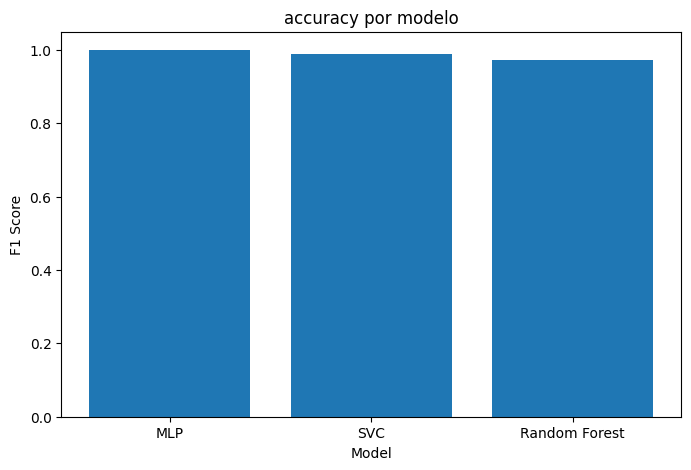

{'MLP': 1.0, 'SVC': 0.9890102048098194, 'Random Forest': 0.9755677126341866}


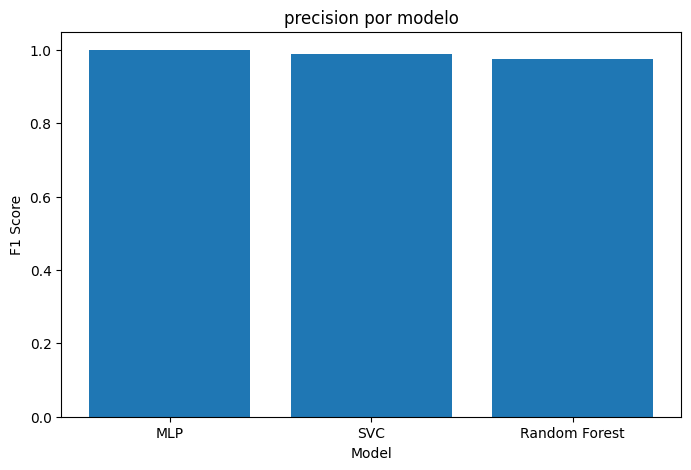

{'MLP': 1.0, 'SVC': 0.9884393063583815, 'Random Forest': 0.9739884393063584}


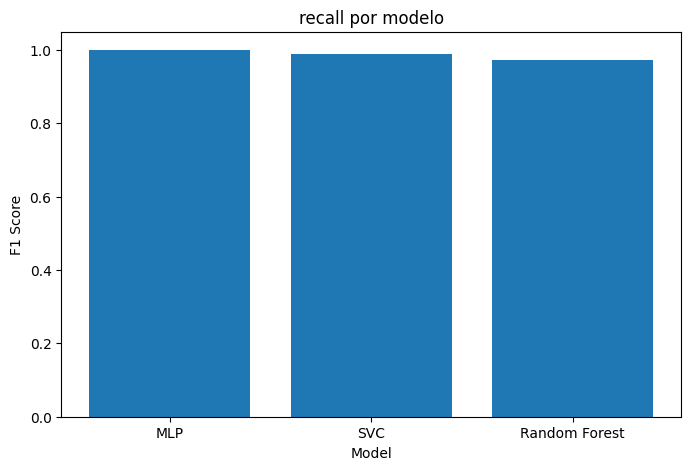

{'MLP': 1.0, 'SVC': 0.9885374746957393, 'Random Forest': 0.9743743223773583}


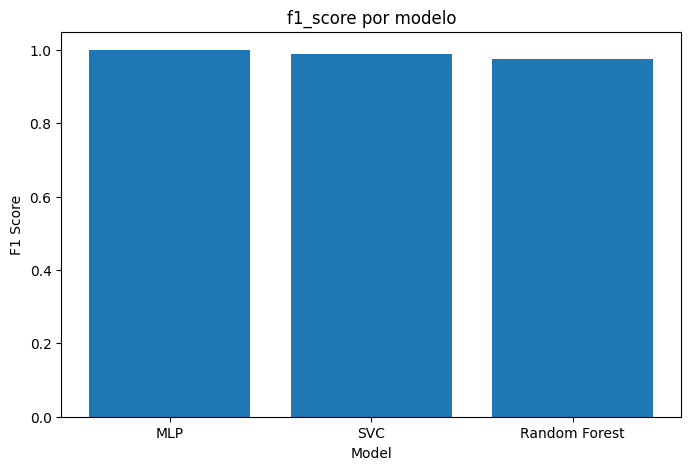

Total de instâncias erradas: 0
Agrupamento de erro por instâncias: 


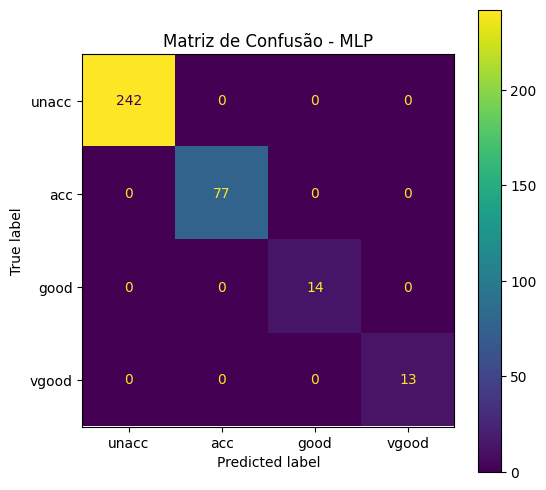

F1-score por classe
unacc -> 1.0
F1-score por classe
acc -> 1.0
F1-score por classe
good -> 1.0
F1-score por classe
vgood -> 1.0
Total de instâncias erradas: 4
Agrupamento de erro por instâncias: 


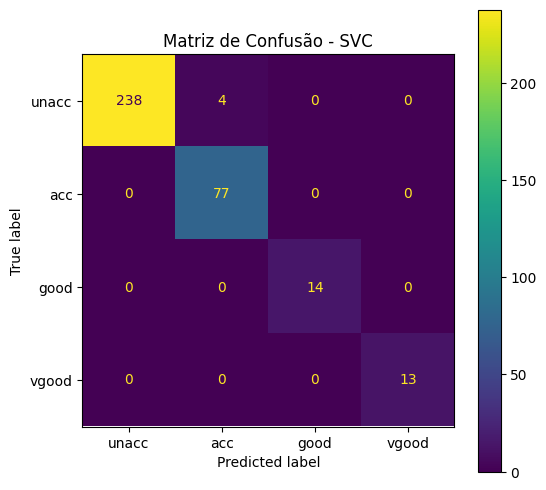

F1-score por classe
unacc -> 0.9916666666666667
F1-score por classe
acc -> 0.9746835443037974
F1-score por classe
good -> 1.0
F1-score por classe
vgood -> 1.0
Total de instâncias erradas: 9
Agrupamento de erro por instâncias: 


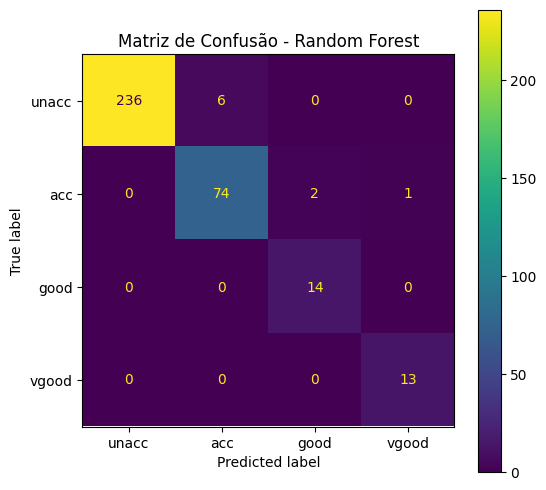

F1-score por classe
unacc -> 0.9874476987447699
F1-score por classe
acc -> 0.9426751592356688
F1-score por classe
good -> 0.9333333333333333
F1-score por classe
vgood -> 0.9629629629629629


In [ ]:
from pandas.core.frame import DataFrame
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, RocCurveDisplay, PrecisionRecallDisplay, classification_report
)
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np



y_predicted  = {}
test_scores =  {name: '' for name in models.keys()}
# Testar a separação atual para cada algoritmo
/    # Treino do modelo atual
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_predicted[nome_algoritmo] = y_pred
    test_scores[nome_algoritmo] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='weighted'),
    'recall': recall_score(y_test, y_pred, average='weighted'),
    'f1_score': f1_score(y_test, y_pred, average='weighted')
      }
print(test_scores)
metrics = [ 'accuracy','precision','recall','f1_score']

for metric in metrics:
  data =  {algorithm: data[metric] for algorithm, data in test_scores.items()}
  print(data)
  plt.figure(figsize=(8, 5))
  plt.bar(data.keys(), data.values())
  plt.title(f'{metric} por modelo')
  plt.xlabel('Model')
  plt.ylabel('F1 Score')
  plt.show()

# Matrizes de confusão das predições

nomes_classes = ["unacc", "acc", "good", "vgood"]
nomes_atributos =  X_test.columns
for nome in models.keys():

    cm = confusion_matrix(y_pred= y_predicted[nome], y_true=y_test, labels=[0,1,2,3])
    fig, ax = plt.subplots(figsize=(6,6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes).plot(ax=ax)
    ax.set_title(f"Matriz de Confusão - {nome}")
    results  =  X_test.copy()
    results['True_label'] =  y_test
    results[f'Predicted_label  with {nome}'] =  y_predicted[nome]
    errors  =  results[results['True_label'] !=  results[f'Predicted_label  with {nome}']]
    print(f'Total de instâncias erradas: {len(errors)}')
    print(f'Agrupamento de erro por instâncias: ')

   # for attr  in nomes_atributos:
  #    print(attr)
  #    display(errors)
 #     error_pairs =  errors.groupby([attr, f'Predicted_label  with {nome}']).size()

#      display(error_pairs)


    plt.show()

    report = classification_report(
    y_test,
    y_predicted[nome],
    target_names=nomes_classes,
    output_dict=True
    )

    for classe in nomes_classes:
      print("F1-score por classe")
      print(f'{classe} -> {report[classe]["f1-score"]}')
